In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# グラフのスタイル設定
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# 1990年から現在までのS&P500とVIXの日次データを取得
print("データを取得中...")
vix = yf.download('^VIX', start='1990-01-01', end='2024-01-01')['Close']
sp500 = yf.download('^GSPC', start='1990-01-01', end='2024-01-01')['Close']

# データフレームの結合
df = pd.concat([vix, sp500], axis=1)
df.columns = ['VIX', 'SP500']
print("データ取得完了。データサイズ:", df.shape)

[*********************100%***********************]  1 of 1 completed

データを取得中...



[*********************100%***********************]  1 of 1 completed

データ取得完了。データサイズ: (8565, 2)


In [4]:
# 半年後（約126営業日後）のS&P500の価格を取得
df['SP500_Future_6M'] = df['SP500'].shift(-126)

# 半年後の収益率（リターン）を計算
df['Return_6M'] = (df['SP500_Future_6M'] - df['SP500']) / df['SP500']

# 直近の半年分は「半年後のデータ」が存在しないため除外
df = df.dropna()

# VIXの水準に応じて4つのフェーズ（群）に分類
# 0-20: 平常, 20-30: 警戒, 30-40: 恐怖, 40以上: パニック
bins = [0, 20, 30, 40, np.inf]
labels = ['1_Normal (<20)', '2_Alert (20-30)', '3_Fear (30-40)', '4_Panic (>40)']
df['VIX_Phase'] = pd.cut(df['VIX'], bins=bins, labels=labels)

print("各フェーズのサンプル数:")
print(df['VIX_Phase'].value_counts().sort_index())

各フェーズのサンプル数:
VIX_Phase
1_Normal (<20)     5146
2_Alert (20-30)    2574
3_Fear (30-40)      516
4_Panic (>40)       203
Name: count, dtype: int64


C:\Users\shota\AppData\Local\Temp\ipykernel_1968\1416131289.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='VIX_Phase', y='Return_6M', data=df, palette="Blues")


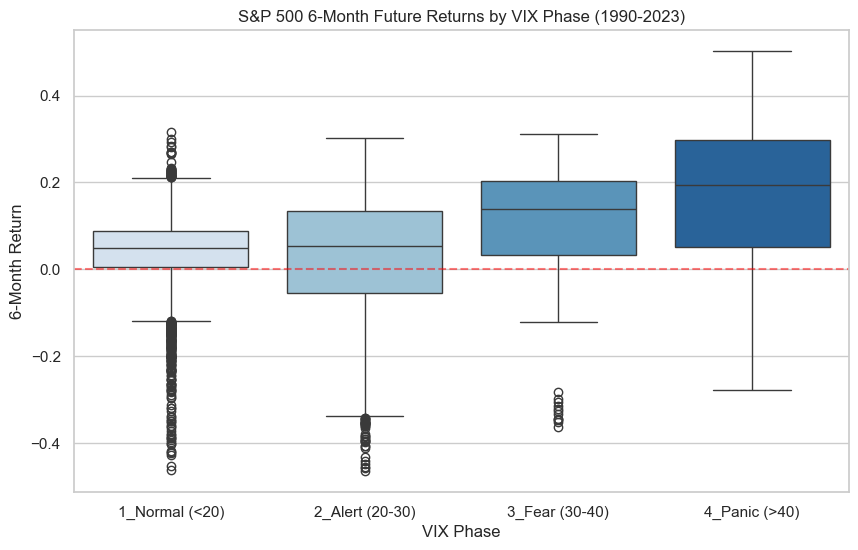

In [5]:
# VIXフェーズごとの半年後リターンを箱ひげ図で可視化
plt.figure(figsize=(10, 6))
sns.boxplot(x='VIX_Phase', y='Return_6M', data=df, palette="Blues")
plt.title("S&P 500 6-Month Future Returns by VIX Phase (1990-2023)")
plt.ylabel("6-Month Return")
plt.xlabel("VIX Phase")
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # リターン0のライン
plt.show()

In [6]:
# 各群のデータをリストとして抽出
groups = [df[df['VIX_Phase'] == label]['Return_6M'].values for label in labels]

# 1. 一元配置分散分析（ANOVA）
# 帰無仮説：すべての群の平均リターンに差はない
f_stat, p_val = stats.f_oneway(*groups)
print("=== ANOVA Results ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("結論: p < 0.05 のため、VIXフェーズ間で将来リターンに統計的な有意差があります。\n")
    
    # 2. Tukeyの多重比較検定（事後検定）
    # どの群間に有意差があるのかを特定する
    print("=== Tukey HSD Test Results ===")
    tukey = pairwise_tukeyhsd(endog=df['Return_6M'], 
                              groups=df['VIX_Phase'], 
                              alpha=0.05)
    print(tukey)
else:
    print("結論: 有意差は確認されませんでした。")

=== ANOVA Results ===
F-statistic: 182.6579
p-value: 9.3954e-115
結論: p < 0.05 のため、VIXフェーズ間で将来リターンに統計的な有意差があります。

=== Tukey HSD Test Results ===
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
 1_Normal (<20) 2_Alert (20-30)  -0.0075 0.0147 -0.0139 -0.0011   True
 1_Normal (<20)  3_Fear (30-40)     0.07    0.0  0.0577  0.0823   True
 1_Normal (<20)   4_Panic (>40)   0.1299    0.0  0.1109   0.149   True
2_Alert (20-30)  3_Fear (30-40)   0.0775    0.0  0.0646  0.0903   True
2_Alert (20-30)   4_Panic (>40)   0.1374    0.0   0.118  0.1568   True
 3_Fear (30-40)   4_Panic (>40)   0.0599    0.0  0.0379   0.082   True
----------------------------------------------------------------------
